202235275 심찬기

In [33]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


path = '/content/drive/MyDrive/Colab Notebooks/TSLA.csv'
df =pd.read_csv(path,header=0)



from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

seq_data = scaler.fit_transform(
    df['Open'].values.reshape(-1,1)
)

from sklearn.model_selection import train_test_split

train, test = train_test_split(seq_data,test_size=0.25,shuffle=False)

In [41]:
def make_sample(data,window):
  train=[]
  target=[]
  for i in range(len(data)-window):
    train.append(data[i:i+window])
    target.append(data[i+window])
  return np.array(train),np.array(target)

X_train, y_train = make_sample(train,3)
X_test, y_test = make_sample(test, 3)
# X_train.shape
# X_test.shape

(2214, 3, 1)

In [38]:
model = Sequential()
model.add(SimpleRNN(10,activation='tanh',input_shape=(3,1)))
model.add(Dense(1,activation='tanh'))
model.compile(optimizer='adam',loss='mse')

In [39]:
history = model.fit(X_train,y_train,epochs=100,verbose=1)
pred=model.predict(X_test)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 2.9159e-05
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9389e-06
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9992e-06
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0073e-06
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.9916e-06
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.0595e-06
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.0460e-06
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9666e-06
Epoch 9/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0980e-06
Epoch 10/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1314e-06
Epoch 11/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8795e-06
Epoch 12/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8910e-06
Epoch 13/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1699e-06
Epoch 14/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.0542e-06
Epoch 15/100
70

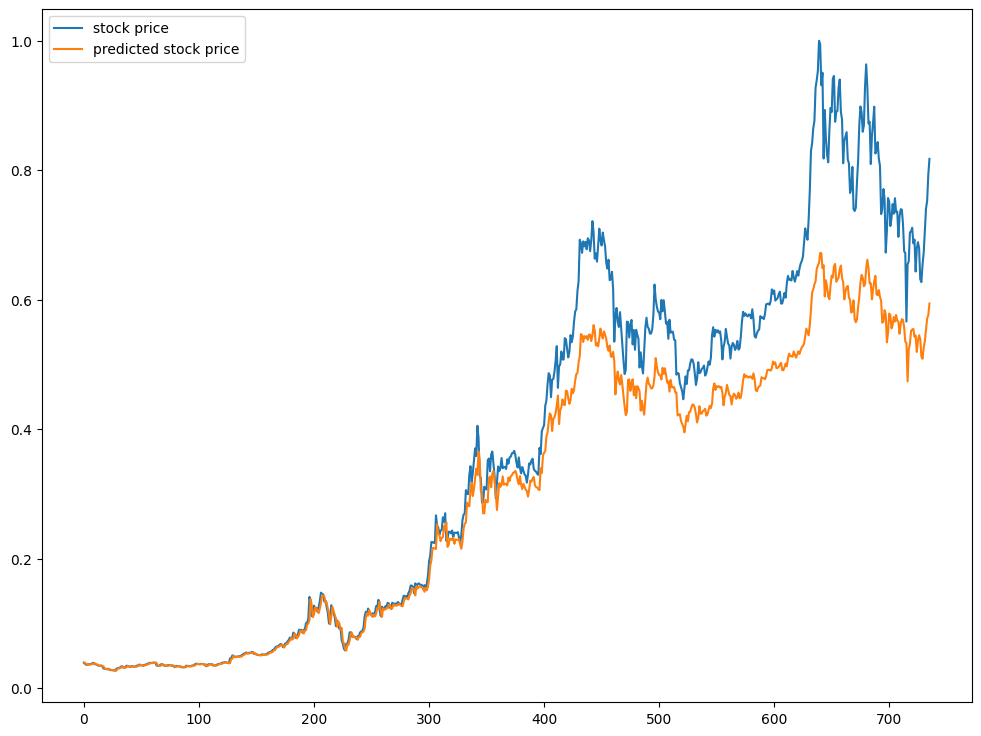

In [40]:
plt.figure(figsize=(12,9))
plt.plot(y_test,label='stock price')
plt.plot(pred,label='predicted stock price')
plt.legend()
plt.show()